In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

os.chdir("../../../..")
os.getcwd()

'/home/augustoni/Documents/PDM'

In [2]:
bilan = pd.read_excel(
    "excels/emission_comparaison.xlsx", sheet_name="emission_bilan_carbone"
)

Text(0, 0.5, 'MWh')

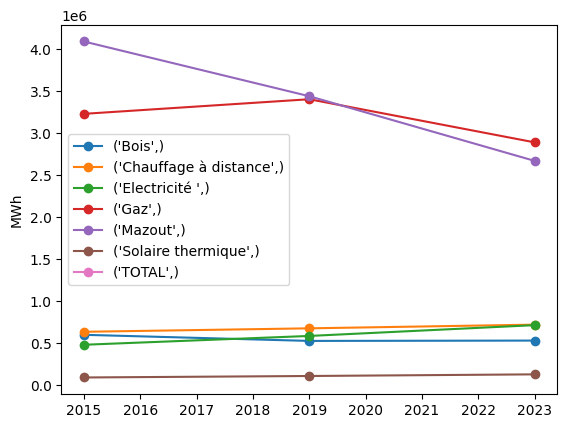

In [3]:
groups = bilan.groupby(["Catégorie"])

# Plot
fig, ax = plt.subplots()
ax.margins(0.05)  # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.Years, group["Activité [MWh]"], marker="o", linestyle="-", label=name)
ax.legend()
plt.ylabel("MWh")

In [26]:
model = pd.read_csv("leure_speed_to_zero_old/building_module.csv").iloc[:, 1:]

model.columns = model.columns.str.replace("energy_consumption_", "")
model.columns = model.columns.str.replace("[MWh]", "")
model.head()

,Country,Years,ambient-heat,coal,district-heating,electricity,gas,heat-pump,heating-oil,other-tech,solar,wood
0,Vaud,2015,151978.980520,347.104607,199672.248886,724913.031763,2.260342e+06,104320.416303,2.480556e+06,0.0,124616.975628,455075.675989
1,Vaud,2019,202334.668029,327.640667,259322.918986,726768.603235,2.381756e+06,137341.059604,2.106932e+06,0.0,147457.269997,498141.720349
2,Vaud,2023,283350.137387,208.746887,255799.457325,609202.199256,2.193647e+06,197754.398079,1.564949e+06,0.0,172475.085160,493123.124259


In [48]:
dic_off_to_model = {
    "bois": "wood",
    "chauffage à distance": "district-heating",
    "electricité ": "electricity",
    "gaz": "gas",
    "mazout": "heating-oil",
    "solaire thermique": "solar",
}

In [43]:
model.columns

Index(['Country', 'Years', 'ambient-heat', 'coal', 'district-heating',
       'electricity', 'gas', 'heat-pump', 'heating-oil', 'other-tech', 'solar',
       'wood'],
      dtype='object')

In [1]:
bilan

NameError: name 'bilan' is not defined

Text(0.02, 0.5, 'MWh')

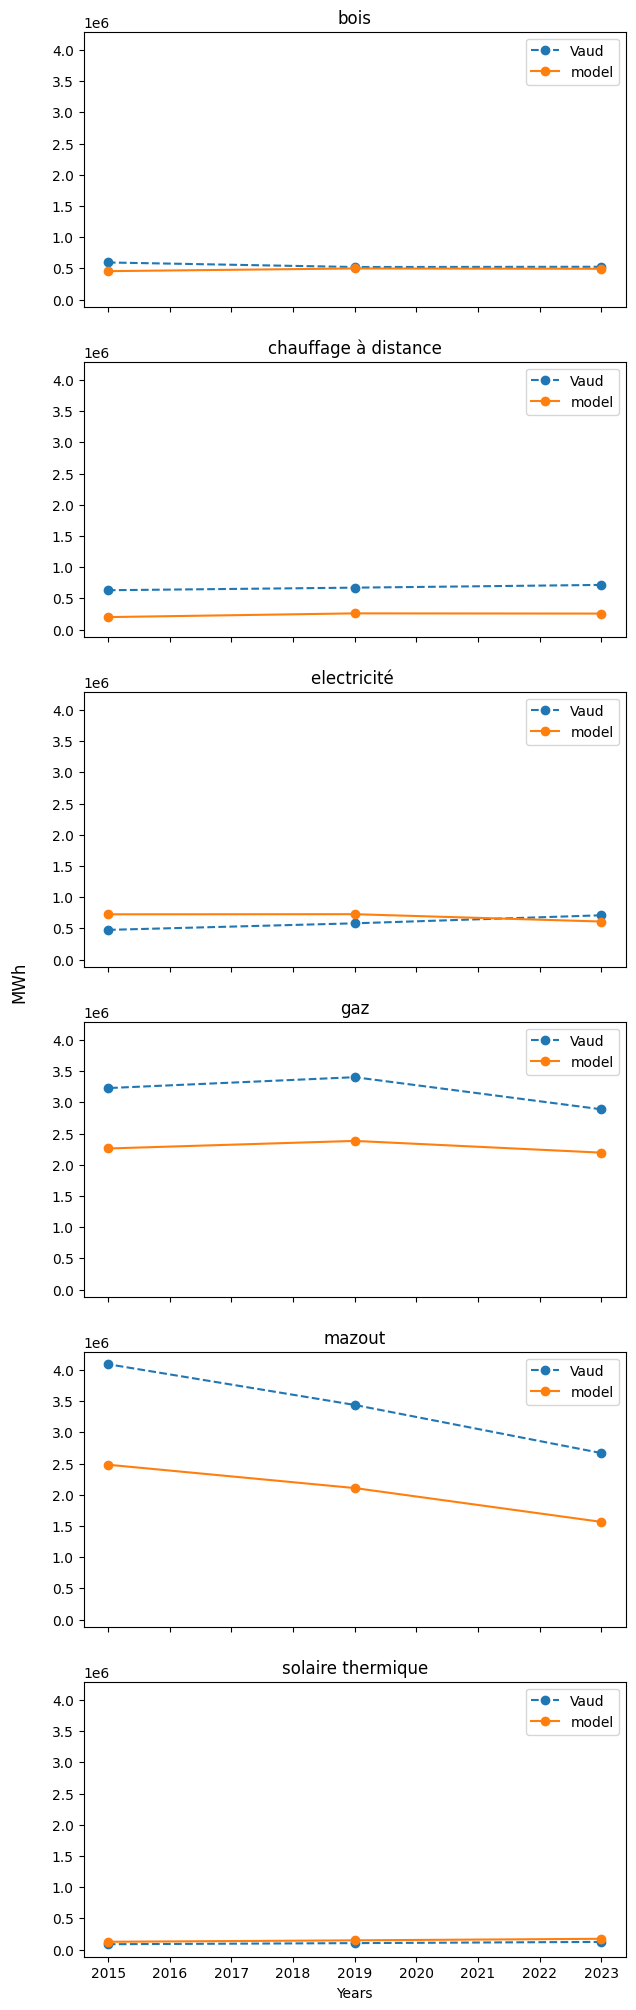

In [61]:
groups = bilan.loc[bilan["Years"] != 1990, :].groupby(["Catégorie"])

# Plot
fig, ax = plt.subplots((6), sharex=True, sharey=True, figsize=(7, 25))
# Optional, just adds 5% padding to the autoscaling
i = 0
for name, group in groups:
    name = name[0].lower()
    ax[i].plot(
        group.Years, group["Activité [MWh]"], marker="o", linestyle="--", label="Vaud"
    )
    model.plot(x="Years", y=dic_off_to_model[name], marker="o", ax=ax[i], label="model")
    ax[i].set_title(name)
    ax[i].legend()

    i += 1

fig.supylabel("MWh")
# plt.ylabel("MWh")

In [22]:
bilan = pd.read_excel("excels/emission_comparaison.xlsx", index_col=0)

In [23]:
bilan.columns

Index(['year', 'total territorial', 'total transport de personnes', '2 roues',
       'Voiture', 'Bus ', 'rail( metro/tram)'],
      dtype='object')

In [13]:
bilan[name]

Transport territorial 
Carbon footprint Canton      132
Speed2zero                 20000
Carbon footprint Canton      102
Speed2zero                 20000
Carbon footprint Canton      110
Speed2zero                 20000
Name: rail( metro/tram), dtype: int64

In [20]:
bilan.loc["Speed2zero ", "year"]

Transport territorial 
Speed2zero     2023
Speed2zero     2015
Speed2zero     2019
Name: year, dtype: int64

Text(0.02, 0.5, 'tCO2eq')

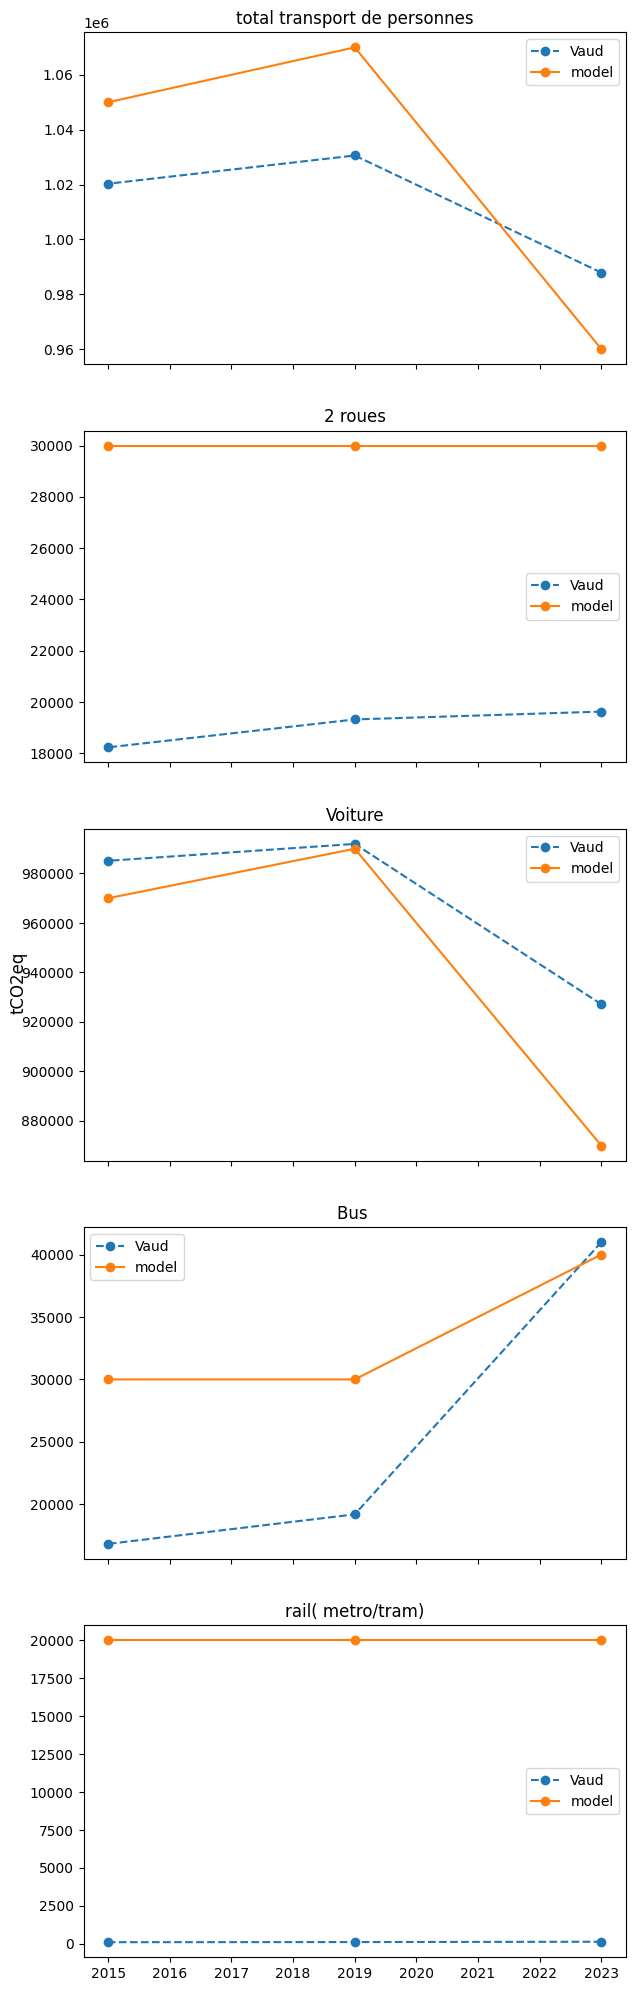

In [32]:
# Plot
fig, ax = plt.subplots((5), sharex=True, figsize=(7, 25))
# Optional, just adds 5% padding to the autoscaling
i = 0
for name in bilan.columns[2:]:
    ax[i].plot(
        bilan.loc["Carbon footprint Canton", "year"],
        bilan.loc["Carbon footprint Canton", name],
        marker="o",
        linestyle="--",
        label="Vaud",
    )
    ax[i].plot(
        bilan.loc["Speed2zero ", "year"],
        bilan.loc["Speed2zero ", name],
        marker="o",
        linestyle="-",
        label="model",
    )
    ax[i].set_title(name)
    ax[i].legend()

    i += 1

fig.supylabel("tCO2eq")

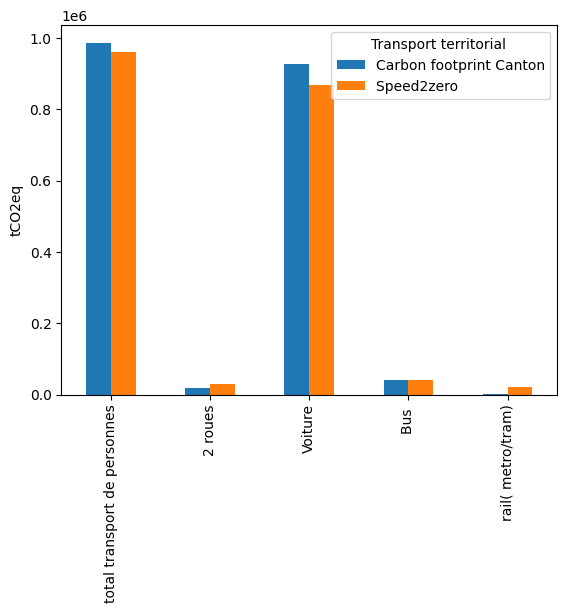

In [30]:
def plot_bilan(bilan, ylabel=""):
    """
    Plot the bilan carbone of the canton of Vaud per year and per category
    Make a plot for each subcategory*
    """

    bilan.T.plot.bar()
    plt.ylabel(ylabel)


plot_bilan(bilan.loc[bilan["year"] == 2023, bilan.columns[2:]], ylabel="tCO2eq")

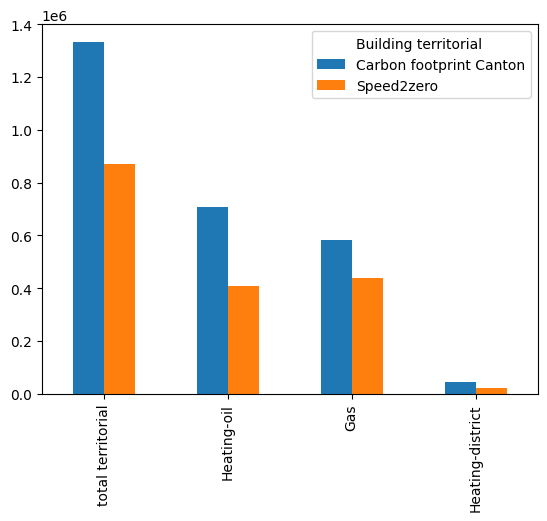

In [7]:
bilan_buildings = pd.read_excel(
    "excels/emission_comparaison.xlsx", index_col=0, sheet_name="Batiment"
)
plot_bilan(bilan_buildings, ylabel="")

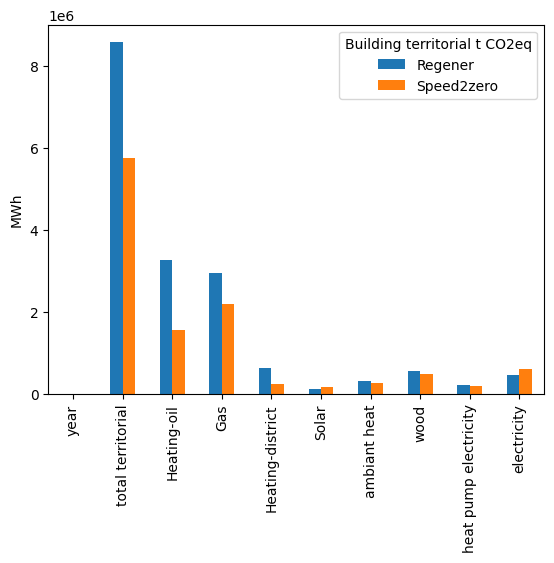

In [8]:
buildings_energy_consumption = pd.read_excel(
    "excels/emission_comparaison.xlsx", index_col=0, sheet_name="building_energy"
)
plot_bilan(buildings_energy_consumption, ylabel="MWh")

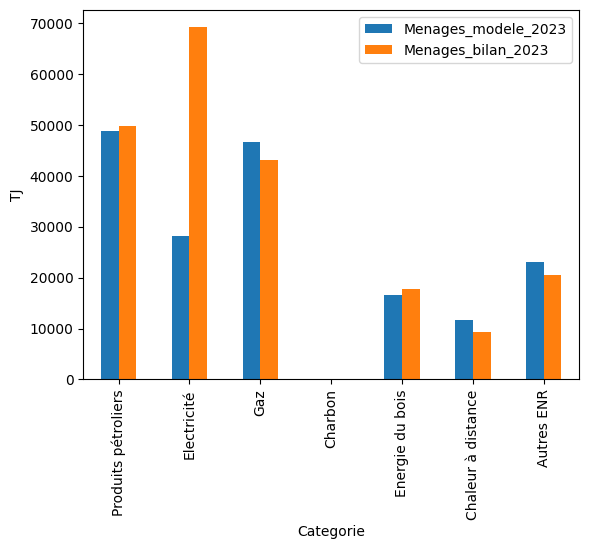

In [26]:
df = pd.read_excel(
    "excels/emission_comparaison.xlsx",
    index_col=0,
    sheet_name="energy_comparison_bilan_suisse",
)

plot_bilan(df.loc[:, ["Menages_modele_2023", "Menages_bilan_2023"]].T, ylabel="TJ")

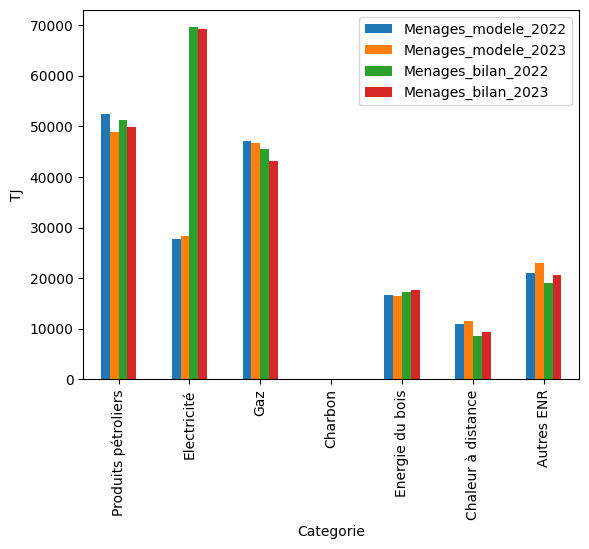

In [27]:
plot_bilan(
    df.loc[
        :,
        [
            "Menages_modele_2022",
            "Menages_modele_2023",
            "Menages_bilan_2022",
            "Menages_bilan_2023",
        ],
    ].T,
    ylabel="TJ",
)

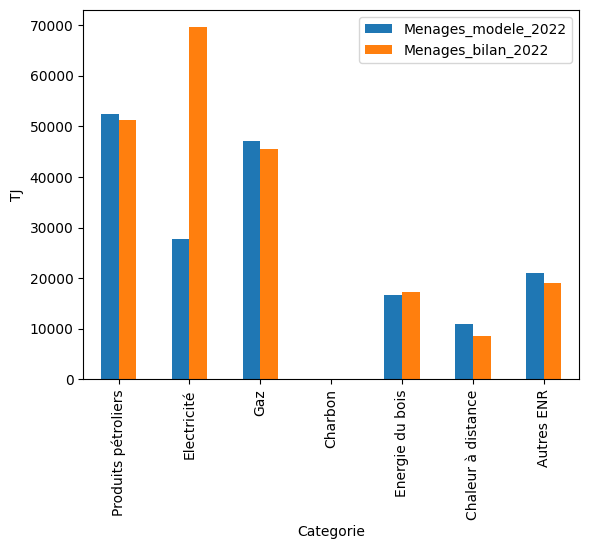

In [28]:
plot_bilan(df.loc[:, ["Menages_modele_2022", "Menages_bilan_2022"]].T, ylabel="TJ")

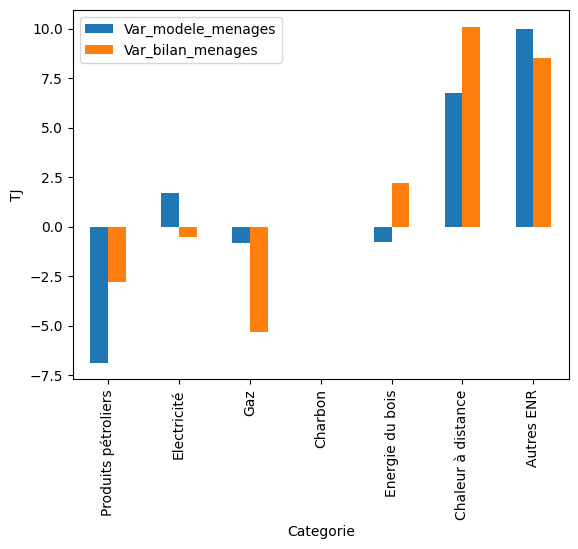

In [29]:
plot_bilan(df.loc[:, ["Var_modele_menages", "Var_bilan_menages"]].T, ylabel="TJ")